In [284]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du fichier
df = pd.read_csv("ventes_trendzone.csv", parse_dates=["date"])

# ── Exploration initiale ──────────────────────────────────────────
print("Dimensions :", df.shape)
print("\nTypes de colonnes :")
print(df.dtypes)
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())
print("\nStatistiques descriptives :")
df.describe()


Dimensions : (500, 13)

Types de colonnes :
transaction_id        str
date                  str
produit               str
categorie             str
quantite            int64
prix_unitaire     float64
remise_pct          int64
vendeur               str
region                str
client_age        float64
client_genre          str
mode_paiement         str
statut                str
dtype: object

Valeurs manquantes par colonne :
transaction_id     0
date               0
produit            0
categorie          0
quantite           0
prix_unitaire      0
remise_pct         0
vendeur            0
region             0
client_age        36
client_genre       0
mode_paiement      0
statut             0
dtype: int64

Statistiques descriptives :


,quantite,prix_unitaire,remise_pct,client_age
count,500.00000,500.000000,500.000000,464.000000
mean,2.00200,72.448800,13.100000,43.885776
std,0.82423,38.714408,13.448112,14.594959
min,0.00000,-59.900000,0.000000,18.000000
25%,1.00000,39.900000,0.000000,31.000000
50%,2.00000,64.900000,10.000000,43.000000
75%,3.00000,89.900000,25.000000,57.000000
max,3.00000,149.900000,40.000000,69.000000


In [285]:
# ── 2.1 Supprimer les doublons ────────────────────────────────────
print("Doublons avant :", df.duplicated(subset="transaction_id").sum())
df = df.drop_duplicates(subset="transaction_id")
print("Doublons après :", df.duplicated(subset="transaction_id").sum())


Doublons avant : 3
Doublons après : 0


In [286]:
# ── 2.2 Corriger les prix négatifs ───────────────────────────────
print("Prix négatifs :", (df["prix_unitaire"] < 0).sum())
df = df[df["prix_unitaire"] > 0]   # on supprime les lignes incohérentes


Prix négatifs : 2


In [287]:
# ── 2.3 corriger les quantités nulles  ───────────────────────────
print("quantités nulles :", (df["quantite"] == 0).sum())
df = df[df["quantite"] > 0] # on supprime les lignes incohérentes

quantités nulles : 1


In [288]:
print("Après nettoyage :", (df["quantite"] == 0).sum())

Après nettoyage : 0


In [289]:
# ── 2.4 Traiter les valeurs manquantes de client_age ─────────────
# Stratégie : remplacer par la médiane (plus robuste que la moyenne)

mediane_age = df["client_age"].median()
print("Médiane âge :", mediane_age)

df["client_age"] = df["client_age"].fillna(mediane_age)

print("Valeurs manquantes restantes :", df["client_age"].isna().sum())

Médiane âge : 43.0
Valeurs manquantes restantes : 0


In [290]:
# Dates invalides
parsed = pd.to_datetime(df["date"], errors="coerce")
invalid_dates = df.loc[parsed.isna(), "date"].unique()

print(invalid_dates)

<StringArray>
['03/02/2025', '2025/01/28', '15-04-2025', '22.03.2025', '01/05/2025']
Length: 5, dtype: str


In [291]:
df["date"] = df["date"].astype(str).str.replace(r"[./]", "-", regex=True)

df["date"] = pd.to_datetime(df["date"], format="mixed", errors="coerce")
df["date"] = df["date"].dt.strftime("%Y-%m-%d")


In [292]:
# Verifier le format final YYYY-MM-DD
print(df["date"].head())

0    2025-02-21
1    2025-02-19
2    2025-04-12
3    2025-04-02
4    2025-01-27
Name: date, dtype: str


In [293]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["date"] = df["date"].dt.strftime("%Y-%m-%d")

In [294]:
# Dates invalides
invalid_dates = df.loc[parsed.isna(), "date"].unique()

print(invalid_dates)

<StringArray>
['2025-03-02', '2025-01-28', '2025-04-15', '2025-03-22', '2025-01-05']
Length: 5, dtype: str


In [295]:
# séparer les lignes

parties = {
    "lignes_50_51": df.iloc[49:51],
    "lignes_100_101": df.iloc[99:101],
    "lignes_150_151": df.iloc[149:151],
    "lignes_200_201": df.iloc[199:201],
    "lignes_400_401": df.iloc[399:401],
    "lignes_449_450": df.iloc[448:450],
    "lignes_499_500": df.iloc[498:500],
}

In [296]:
df["date"] = pd.to_datetime(df["date"], errors="coerce") 

# Ajouter des colonnes calculées
df["chiffre_affaires"] = df["quantite"] * df["prix_unitaire"] * (1 - df["remise_pct"]/100)
df["mois"] = df["date"].dt.month
df["mois_nom"] = df["date"].dt.strftime("%b")
df["trimestre"] = df["date"].dt.quarter

In [297]:
# pour exporter le fichier corrigé en csv
df.to_csv("ventes_trendzone_corrige.csv", index=False, encoding="utf-8-sig")

In [298]:
# Chargement du fichier
df = pd.read_csv('ventes_trendzone_corrige.csv')

In [299]:

# ── Q1 : Évolution du CA mensuel ─────────────────────────────────
ca_mensuel = df.groupby("mois_nom")["chiffre_affaires"].sum().reset_index()


In [300]:
# Réordonner les mois chronologiquement
ordre_mois = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]

In [301]:
# Réordonner les mois chronologiquement sur le graphique
ordre_mois = ["Jan", "Feb", "Mar", "Apr"]

ca_mensuel["mois_nom"] = pd.Categorical(
    ca_mensuel["mois_nom"],
    categories=ordre_mois,
    ordered=True
)

ca_mensuel = ca_mensuel.sort_values("mois_nom")

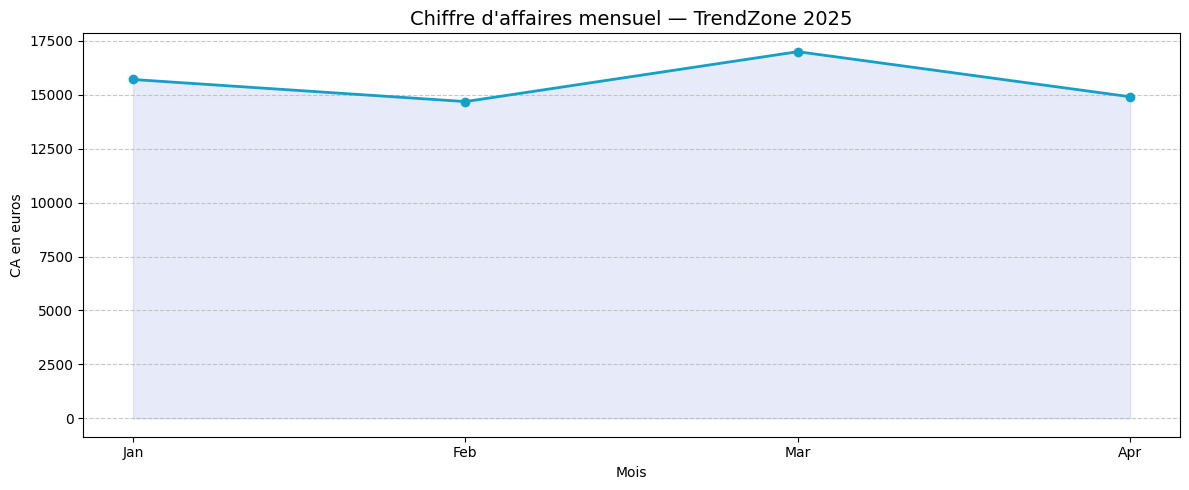

In [302]:

plt.figure(figsize=(12, 5))
plt.plot(ca_mensuel["mois_nom"], ca_mensuel["chiffre_affaires"],
         marker="o", color="#15A0CA", linewidth=2)
plt.fill_between(range(len(ca_mensuel)), ca_mensuel["chiffre_affaires"],
                 alpha=0.1, color="#153FCA")
plt.title("Chiffre d'affaires mensuel — TrendZone 2025", fontsize=14)
plt.xlabel("Mois")
plt.ylabel("CA en euros")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Interprétation à écrire en Markdown sous cette cellule :
# "Le CA atteint son pic en Mars tandis que Février est le plus faible .La tendance générale est plutôt stable sur la période, avec des variations modérées d’un mois à l’autre. 


Le CA atteint son pic en Mars tandis que Février est le plus faible .La tendance générale est plutôt stable sur la période, avec des variations modérées d’un mois à l’autre. 

In [303]:
# ── Q2 : Variation du CA par produit ─────────────────────────────────
cat_col = "categorie"
ca_col = "chiffre_affaires"
ca_cat = df.groupby(cat_col)[ca_col].sum().reset_index()


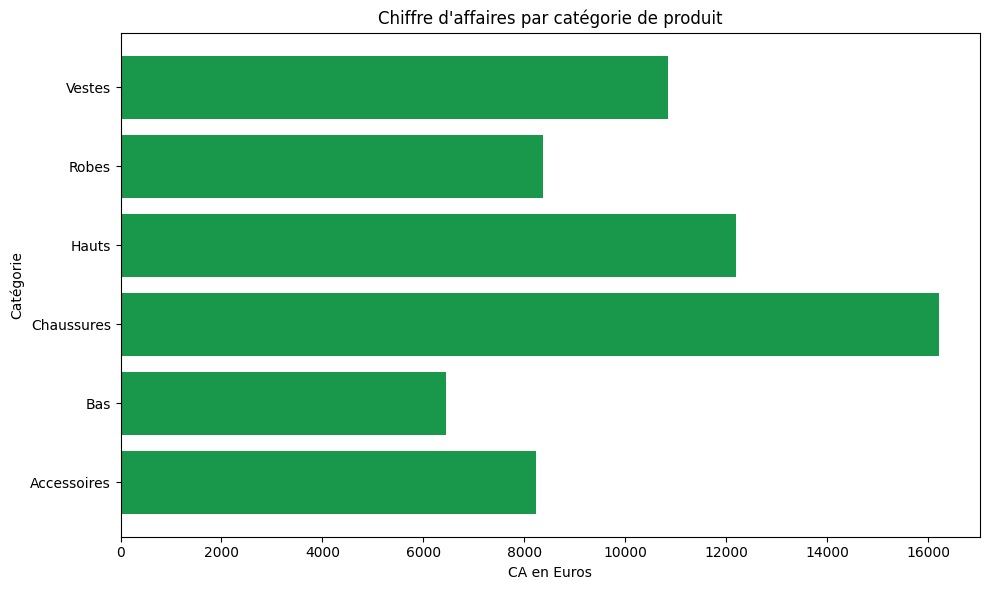

In [304]:
plt.figure(figsize=(10,6))
plt.barh(ca_cat[cat_col], ca_cat[ca_col], color="#19974A")
plt.title('Chiffre d\'affaires par catégorie de produit')
plt.xlabel("CA en Euros")
plt.ylabel('Catégorie')
plt.tight_layout()
plt.show()

Le graphique montre que le chiffre d’affaires est dominé par la catégorie Chaussures (avec +de 16000 euros de vente), suivie des Hauts, ce qui indique une forte demande pour ces produits. En revanche, la catégorie Bas est la moins performante. 

In [305]:
df = pd.read_csv("ventes_trendzone_corrige.csv")

In [306]:
# ── Q3 : Variation du CA par région ─────────────────────────────────
ca_region = df.groupby("region")["chiffre_affaires"].sum().sort_values(ascending=False).reset_index()

In [307]:
print(ca_region.head())


       region  chiffre_affaires
0   Marseille          8705.815
1       Paris          7829.450
2      Nantes          7222.595
3  Strasbourg          7049.415
4        Lyon          6643.765


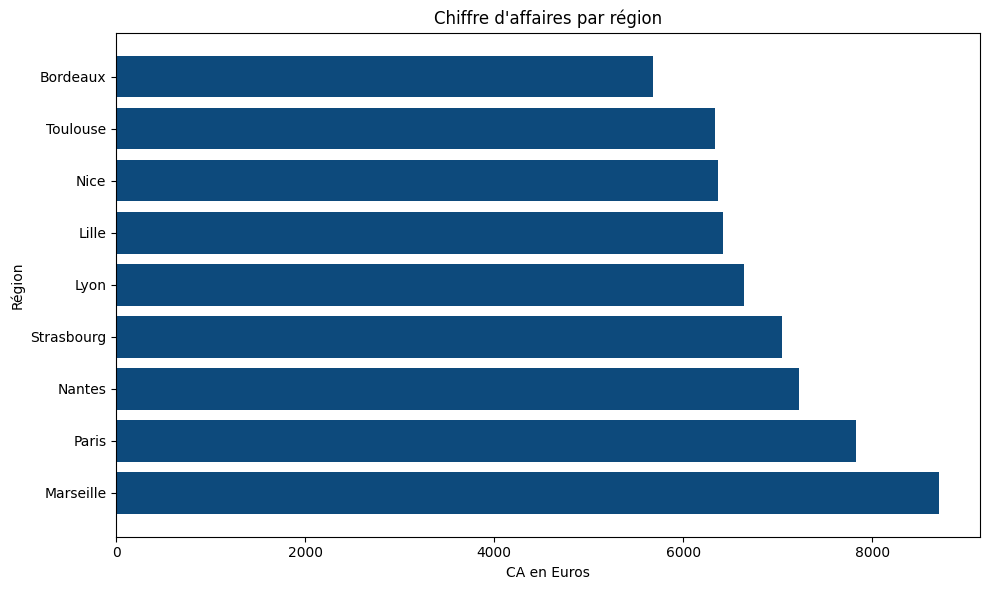

In [308]:
plt.figure(figsize=(10,6))

ca_col = "chiffre_affaires"
region_col = "region"
plt.barh(ca_region[region_col], ca_region[ca_col], color="#0D4A7C")
plt.title('Chiffre d\'affaires par région')
plt.xlabel("CA en Euros")
plt.ylabel('Région')
plt.tight_layout()
plt.show()


La région la plus performante est Marseille, avec le chiffre d’affaires le plus élevé (plus de 8000 Euros). Bordeaux enregistre le chiffre d’affaire le plus faible. 

In [309]:
# ── Q4 : Profil des meilleurs clients ─────────────────────────────────
df['date'] = pd.to_datetime(df['date'])
df['client_age'] = pd.to_numeric(df['client_age'], errors='coerce')
print('Genres uniques:', df['client_genre'].unique())
print('Âges - min/max/mean:', df['client_age'].min(), df['client_age'].max(), df['client_age'].mean())
ca_par_client = df.groupby(['client_genre', pd.cut(df['client_age'], bins=5)]).agg({'chiffre_affaires': ['sum', 'count', 'mean']}).round(2)
print('CA croisé genre/âge:')
print(ca_par_client)
top_clients = df.groupby(['client_genre', pd.cut(df['client_age'], bins=5)])['chiffre_affaires'].sum().sort_values(ascending=False).head(10)
print('Top 10 segments CA:')
print(top_clients)

Genres uniques: <StringArray>
['H', 'NR', 'F']
Length: 3, dtype: str
Âges - min/max/mean: 18.0 69.0 43.69230769230769
CA croisé genre/âge:
                            chiffre_affaires              
                                         sum count    mean
client_genre client_age                                   
F            (17.949, 28.2]          5715.34    44  129.89
             (28.2, 38.4]            6354.13    41  154.98
             (38.4, 48.6]            5889.13    44  133.84
             (48.6, 58.8]            3078.44    28  109.94
             (58.8, 69.0]            4544.88    40  113.62
H            (17.949, 28.2]          2635.88    25  105.44
             (28.2, 38.4]            5148.06    43  119.72
             (38.4, 48.6]            5918.48    53  111.67
             (48.6, 58.8]            2489.68    30   82.99
             (58.8, 69.0]            5302.94    39  135.97
NR           (17.949, 28.2]          1401.91    12  116.83
             (28.2, 38.4]          

  client_genre  chiffre_affaires
0            F         25581.925
1            H         21495.060
2           NR         15195.655


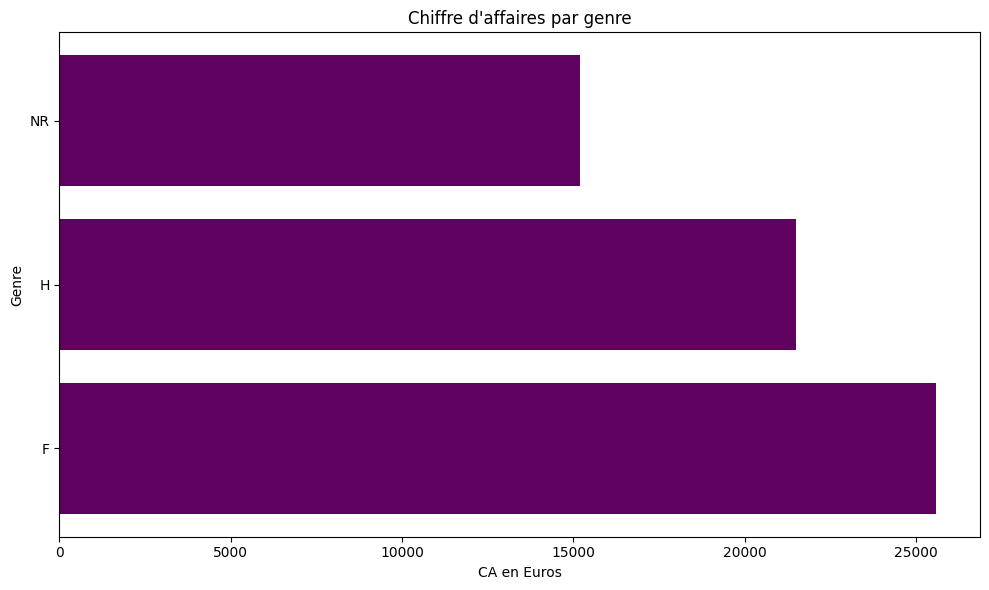

In [310]:
# Histogramme client_genre vs ca ────────────────────────────────
ca_genre = df.groupby("client_genre")["chiffre_affaires"].sum().reset_index()

print(ca_genre.head())

plt.figure(figsize=(10,6))

ca_col = "chiffre_affaires"
genre_col = "client_genre"

plt.barh(ca_genre[genre_col], ca_genre[ca_col], color="#5F025F")
plt.title('Chiffre d\'affaires par genre')
plt.xlabel("CA en Euros")
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

Les femmes sont les plus performantes en CA avec plus de 25000 €.

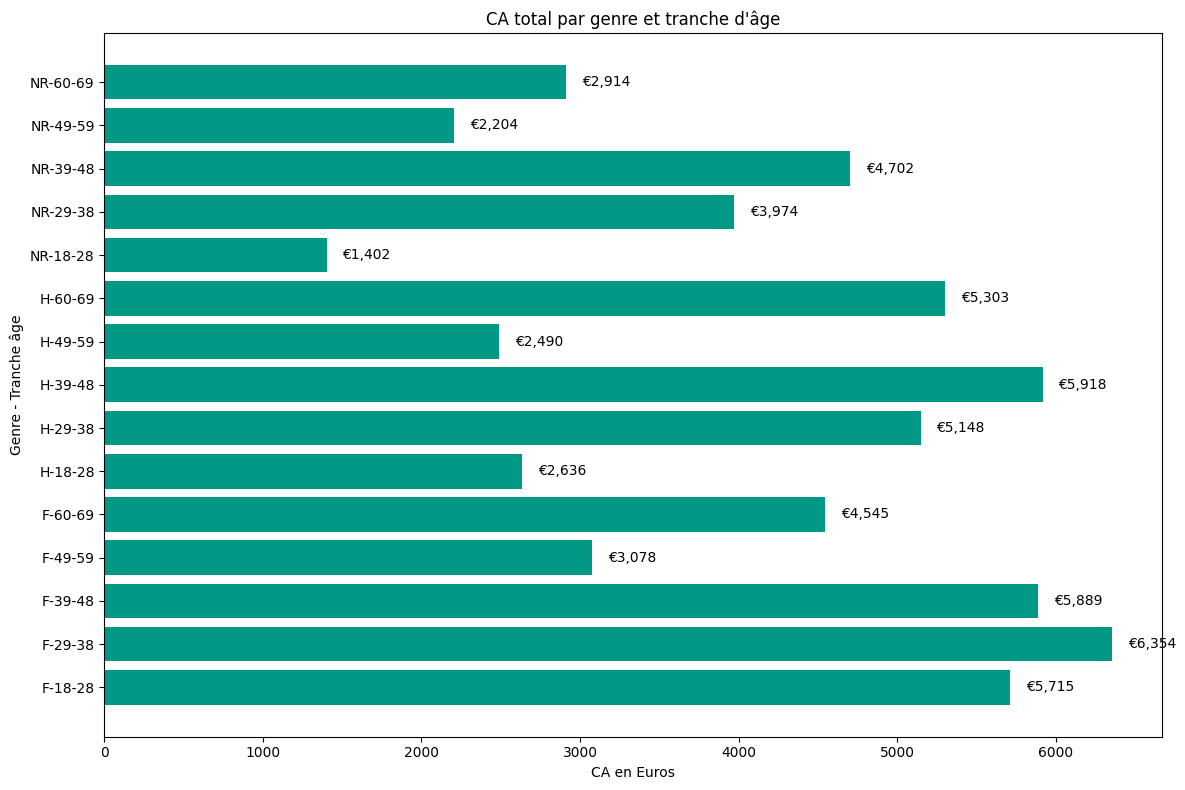

In [311]:
# Groupby avec client_age 
df['age_group'] = pd.cut(df['client_age'], bins=5, labels=['18-28', '29-38', '39-48', '49-59', '60-69'])
ca_genre_age = df.groupby(['client_genre', 'age_group'])['chiffre_affaires'].sum().reset_index()
ca_genre_age['label'] = ca_genre_age['client_genre'] + '-' + ca_genre_age['age_group'].astype(str)

plt.figure(figsize=(12,8))
ca_col = 'chiffre_affaires'
label_col = 'label'
bars = plt.barh(ca_genre_age[label_col], ca_genre_age[ca_col], color="#019985")
plt.title('CA total par genre et tranche d\'âge')
plt.xlabel('CA en Euros')
plt.ylabel('Genre - Tranche âge')

# Boucle MODIFIÉE : labels avec CA (age déjà dans label)
for i, bar in enumerate(bars):
    v = ca_genre_age[ca_col][i]
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, 
             f'€{v:,.0f}', va='center', fontsize=10)

plt.tight_layout()

plt.show()

À partir du tableau CA croisé (F/H/NR par tranches d'âge 18-69 ans), les top segments sont F 29-38 ans (6354 €), H 39-48 ans (5918 €) et F 39-48 ans (5889 €). Les NR (39-48 ans) représentent un CA de 4702 €.Les seniors (60+ ans) performent bien chez H/F (5303 € et 4545 €).

In [315]:
# ── Q5 : Les vendeurs les plus performants ─────────────────────────────────
vendeurs_perf = df.groupby('vendeur').agg({'chiffre_affaires': ['sum', 'mean', 'count']}).round(2)
vendeurs_perf.columns = ['CA_total', 'CA_moyen', 'Nb_transactions']
vendeurs_perf.sort_values('CA_total', ascending=False)

,CA_total,CA_moyen,Nb_transactions
vendeur,,,
Antoine,11666.94,138.89,84
Marc,10157.64,123.87,82
Sophia,9404.90,130.62,72
Laure,9025.72,118.76,76
Julie,8031.93,111.55,72
Kevin,7083.98,126.50,56
Chloé,6901.52,132.72,52


   vendeur  chiffre_affaires
0  Antoine         11666.940
1     Marc         10157.645
2   Sophia          9404.895
3    Laure          9025.720
4    Julie          8031.930


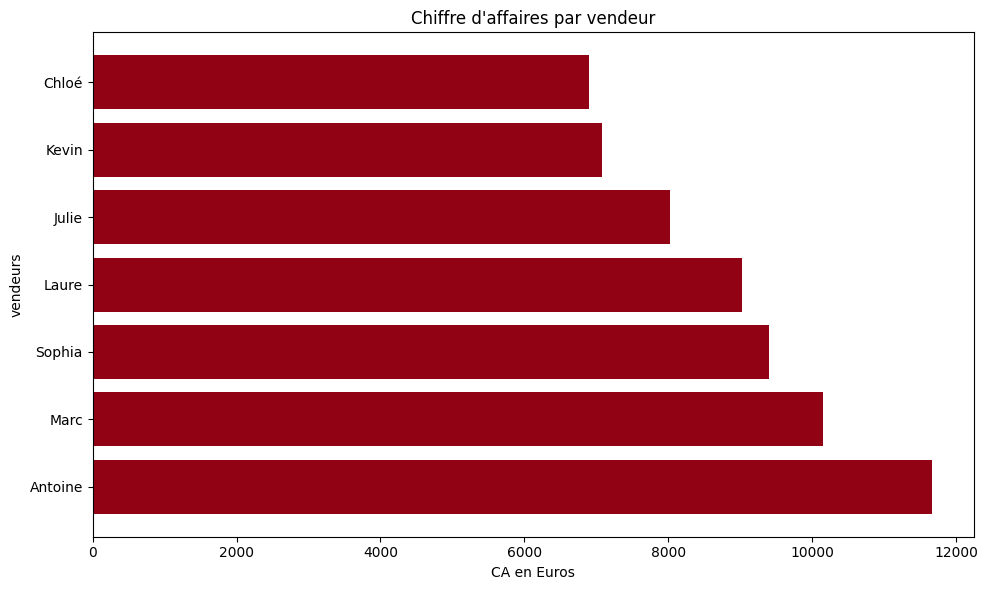

In [340]:
# Histogramme vendeurs performants vs ca ────────────────────────────────
ca_vendeur = df.groupby("vendeur")["chiffre_affaires"].sum().sort_values(ascending=False).reset_index()

print(ca_vendeur.head())

plt.figure(figsize=(10,6))

ca_col = "chiffre_affaires"
vendeur_col = "vendeur"

plt.barh(ca_vendeur[vendeur_col], ca_vendeur[ca_col], color="#910215")
plt.title('Chiffre d\'affaires par vendeur')
plt.xlabel("CA en Euros")
plt.ylabel('vendeurs')
plt.tight_layout()
plt.show()

Ce graphique représente le classement des vendeurs par rapport au CA. On remarque que Antoine est le vendeur le plus performant en chiffre d’affaires total, avec environ 11 667 €, devant Marc (~10 158 €) et Sophia (~9 405 €)

   vendeur    ca_moyen  nb_transactions
0  Antoine  138.892143               84
1    Chloé  132.721635               52
6   Sophia  130.623542               72
3    Kevin  126.499732               56
5     Marc  123.873720               82


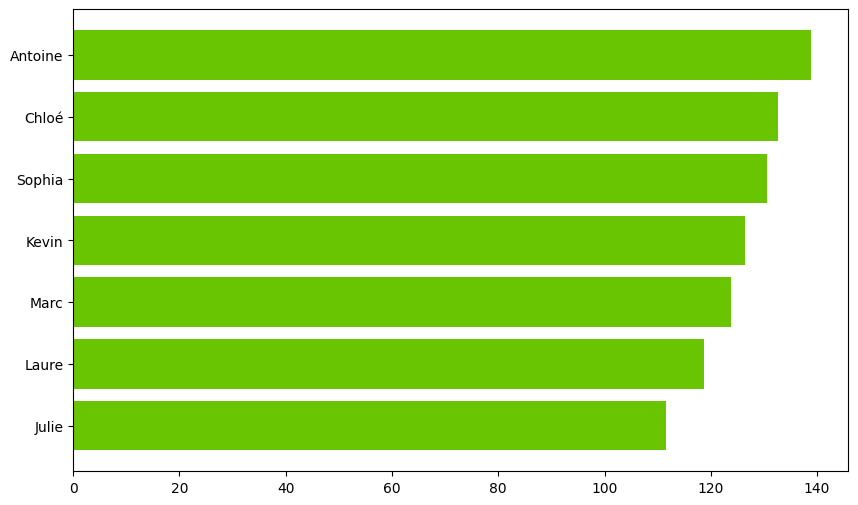

In [338]:
# Histogramme vendeurs performants vs ca_moyen avec une courbe de variation de nbre de transactions ────────────────────────────────

vendeurs_perf = df.groupby("vendeur").agg(
    ca_moyen=("chiffre_affaires", "mean"),
    nb_transactions=("chiffre_affaires", "count")
).reset_index().sort_values("ca_moyen", ascending=False)

print(vendeurs_perf.head())

plt.figure(figsize=(10, 6))

plt.barh(vendeurs_perf["vendeur"], vendeurs_perf["ca_moyen"], color="#69C501")

plt.gca().invert_yaxis()


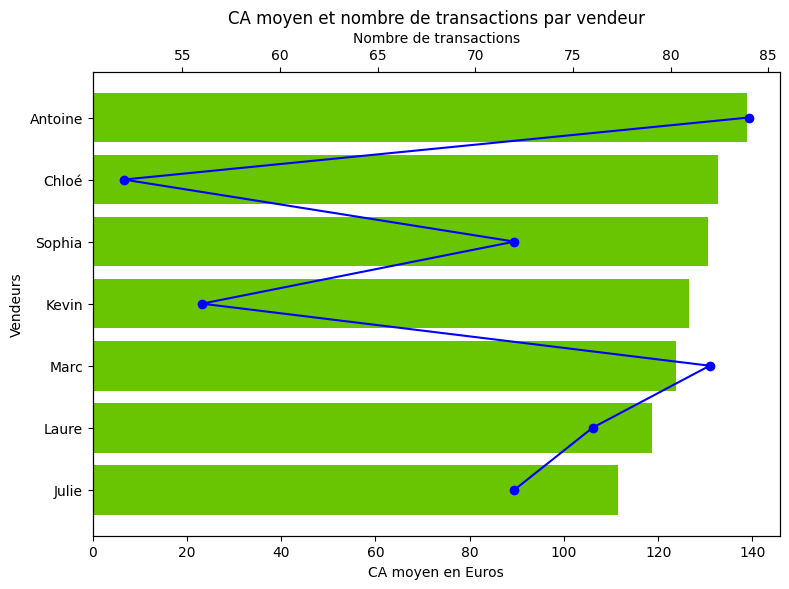

In [342]:
# CA moyen + nombre de transactions par vendeur
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.barh(vendeurs_perf["vendeur"], vendeurs_perf["ca_moyen"], color="#69C501")
ax1.set_xlabel("CA moyen en Euros")
ax1.set_ylabel("Vendeurs")
ax1.set_title("CA moyen et nombre de transactions par vendeur")
ax1.invert_yaxis()

ax2 = ax1.twiny()
ax2.plot(vendeurs_perf["nb_transactions"], vendeurs_perf["vendeur"], color="blue", marker="o")
ax2.set_xlabel("Nombre de transactions")

plt.tight_layout()
plt.show()

Cette figure permet de voir si un vendeur a un CA moyen élevé tout en gardant un bon nombre de transactions. Dans ce cas, le vendeur Antoine reste le plus fort en volume global, avec un CA moyen élevé et le plus grand nombre de transactions parmi les meilleurs vendeurs. 